Predict short-term electricity load in Panama using past load data and temporal features through a Gated Recurrent Neural Network (LSTM and GRU) model.

In [2]:
import numpy as np 
import pandas as pd 
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import GRU, LSTM, Dense, Dropout, Bidirectional , LayerNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import AdamW
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/shortterm-electricity-load-forecasting-panama/train_dataframes.xlsx
/kaggle/input/shortterm-electricity-load-forecasting-panama/STLF Panama dataset demo-.ipynb
/kaggle/input/shortterm-electricity-load-forecasting-panama/continuous dataset.csv
/kaggle/input/shortterm-electricity-load-forecasting-panama/test_dataframes.xlsx
/kaggle/input/shortterm-electricity-load-forecasting-panama/Columns metadata and train-test splits details.pdf
/kaggle/input/shortterm-electricity-load-forecasting-panama/Animated_3D_plot.gif
/kaggle/input/shortterm-electricity-load-forecasting-panama/weekly pre-dispatch forecast.csv


In [3]:
continuous_df = pd.read_csv("/kaggle/input/shortterm-electricity-load-forecasting-panama/continuous dataset.csv")

In [4]:
continuous_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48048 entries, 0 to 48047
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    48048 non-null  object 
 1   nat_demand  48048 non-null  float64
 2   T2M_toc     48048 non-null  float64
 3   QV2M_toc    48048 non-null  float64
 4   TQL_toc     48048 non-null  float64
 5   W2M_toc     48048 non-null  float64
 6   T2M_san     48048 non-null  float64
 7   QV2M_san    48048 non-null  float64
 8   TQL_san     48048 non-null  float64
 9   W2M_san     48048 non-null  float64
 10  T2M_dav     48048 non-null  float64
 11  QV2M_dav    48048 non-null  float64
 12  TQL_dav     48048 non-null  float64
 13  W2M_dav     48048 non-null  float64
 14  Holiday_ID  48048 non-null  int64  
 15  holiday     48048 non-null  int64  
 16  school      48048 non-null  int64  
dtypes: float64(13), int64(3), object(1)
memory usage: 6.2+ MB


In [5]:
continuous_df.head()

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
3,2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
4,2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


In [6]:
weekly_df = pd.read_csv("/kaggle/input/shortterm-electricity-load-forecasting-panama/weekly pre-dispatch forecast.csv")

In [7]:
weekly_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40152 entries, 0 to 40151
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   datetime       40152 non-null  object 
 1   load_forecast  40152 non-null  float64
dtypes: float64(1), object(1)
memory usage: 627.5+ KB


In [8]:
weekly_df.head()

,datetime,load_forecast
0,1/2/2016 0:00,1056.9
1,1/2/2016 1:00,1057.1
2,1/2/2016 2:00,996.5
3,1/2/2016 3:00,955.8
4,1/2/2016 4:00,918.0


In [4]:
train_df = pd.read_excel("/kaggle/input/shortterm-electricity-load-forecasting-panama/train_dataframes.xlsx")
test_df = pd.read_excel("/kaggle/input/shortterm-electricity-load-forecasting-panama/test_dataframes.xlsx")

In [5]:
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36720 entries, 0 to 36719
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    36720 non-null  datetime64[ns]
 1   week_X-2    36720 non-null  float64       
 2   week_X-3    36720 non-null  float64       
 3   week_X-4    36720 non-null  float64       
 4   MA_X-4      36720 non-null  float64       
 5   dayOfWeek   36720 non-null  int64         
 6   weekend     36720 non-null  int64         
 7   holiday     36720 non-null  int64         
 8   Holiday_ID  36720 non-null  int64         
 9   hourOfDay   36720 non-null  int64         
 10  T2M_toc     36720 non-null  float64       
 11  DEMAND      36720 non-null  float64       
dtypes: datetime64[ns](1), float64(6), int64(5)
memory usage: 3.4 MB
None


In [11]:
print(train_df.head())

             datetime  week_X-2  week_X-3  week_X-4      MA_X-4  dayOfWeek  \
0 2015-01-31 01:00:00  962.2865  906.9580  970.3450  938.004850          1   
1 2015-01-31 02:00:00  933.3221  863.5135  912.1755  900.284075          1   
2 2015-01-31 03:00:00  903.9817  848.4447  900.2688  881.704325          1   
3 2015-01-31 04:00:00  900.9995  839.8821  889.9538  876.458825          1   
4 2015-01-31 05:00:00  904.3481  847.1073  893.6865  879.190775          1   

   weekend  holiday  Holiday_ID  hourOfDay    T2M_toc    DEMAND  
0        1        0           0          1  25.308496  954.2018  
1        1        0           0          2  25.141443  913.8660  
2        1        0           0          3  25.006738  903.3637  
3        1        0           0          4  24.899713  889.0806  
4        1        0           0          5  24.821558  910.1472  


In [12]:
print(test_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    168 non-null    datetime64[ns]
 1   week_X-2    168 non-null    float64       
 2   week_X-3    168 non-null    float64       
 3   week_X-4    168 non-null    float64       
 4   MA_X-4      168 non-null    float64       
 5   dayOfWeek   168 non-null    int64         
 6   weekend     168 non-null    int64         
 7   holiday     168 non-null    int64         
 8   Holiday_ID  168 non-null    int64         
 9   hourOfDay   168 non-null    int64         
 10  T2M_toc     168 non-null    float64       
 11  DEMAND      168 non-null    float64       
dtypes: datetime64[ns](1), float64(6), int64(5)
memory usage: 15.9 KB
None


In [9]:
path = "/kaggle/input/shortterm-electricity-load-forecasting-panama/continuous dataset.csv"
df = pd.read_csv(path)
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime')
df = df.set_index('datetime')
df.head()

,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
datetime,,,,,,,,,,,,,,,,
2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


In [14]:
df.columns

Index(['nat_demand', 'T2M_toc', 'QV2M_toc', 'TQL_toc', 'W2M_toc', 'T2M_san',
       'QV2M_san', 'TQL_san', 'W2M_san', 'T2M_dav', 'QV2M_dav', 'TQL_dav',
       'W2M_dav', 'Holiday_ID', 'holiday', 'school'],
      dtype='object')

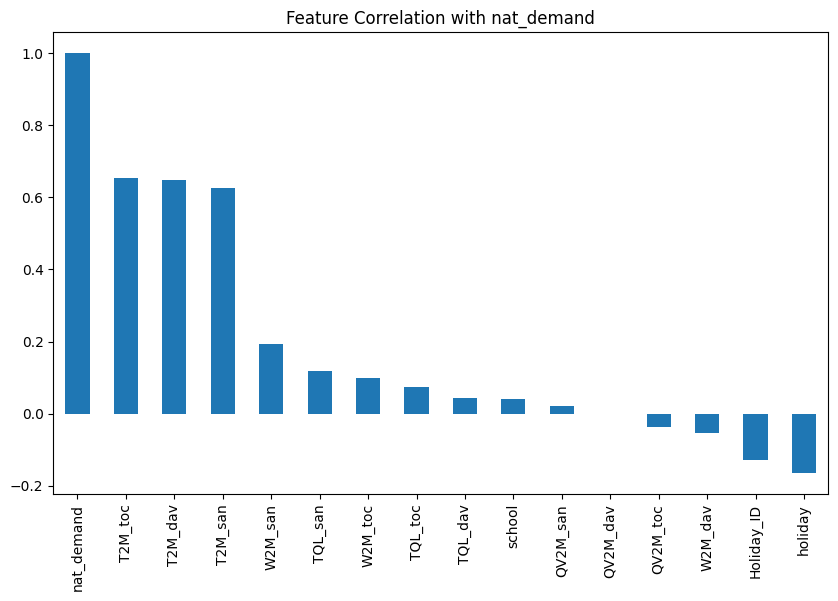

In [15]:
plt.figure(figsize=(10,6))
plt.title("Feature Correlation with nat_demand")
df.corr()['nat_demand'].sort_values(ascending=False).plot(kind='bar')
plt.show()

In [10]:
z_scores = stats.zscore(df)
print("Z-scores:", z_scores)

Z-scores: [[-1.10650846 -0.91548985  0.1641454  ... -0.2239267  -0.25916053
  -1.63513772]
 [-1.40936908 -0.89519877  0.21200108 ... -0.2239267  -0.25916053
  -1.63513772]
 [-1.47136155 -0.87250336  0.28328868 ... -0.2239267  -0.25916053
  -1.63513772]
 ...
 [-0.52742377 -0.25542871  1.32899348 ... -0.2239267  -0.25916053
   0.61156928]
 [-0.73539298 -0.31730375  1.33855155 ... -0.2239267  -0.25916053
   0.61156928]
 [-0.88146552 -0.38722965  1.32436658 ... -0.2239267  -0.25916053
   0.61156928]]


In [11]:
threshold = 3
outliers = df[np.abs(z_scores) > threshold]
print("Outliers:", outliers)

Outliers:                      nat_demand    T2M_toc  QV2M_toc   TQL_toc    W2M_toc  \
datetime                                                                    
2015-01-06 10:00:00   1384.2441  28.865076  0.017545  0.003212  30.080409   
2015-01-08 10:00:00   1348.9510  28.399377  0.016773  0.025772  33.816953   
2015-01-08 11:00:00   1365.6284  29.004724  0.016819  0.031982  33.338703   
2015-01-08 12:00:00   1343.4717  29.328638  0.016871  0.048721  32.322581   
2015-01-08 13:00:00   1371.5959  29.372705  0.016870  0.065063  31.365933   
...                         ...        ...       ...       ...        ...   
2020-06-12 05:00:00    871.4360  25.773309  0.018471  0.281250   0.850584   
2020-06-12 12:00:00   1253.1163  28.229669  0.018601  0.286499  12.231111   
2020-06-12 13:00:00   1254.7187  28.432855  0.018403  0.282837  12.915897   
2020-06-13 18:00:00   1088.7196  29.125208  0.018113  0.073242   2.783583   
2020-06-13 19:00:00   1182.4094  28.674036  0.018838  0.052139   2

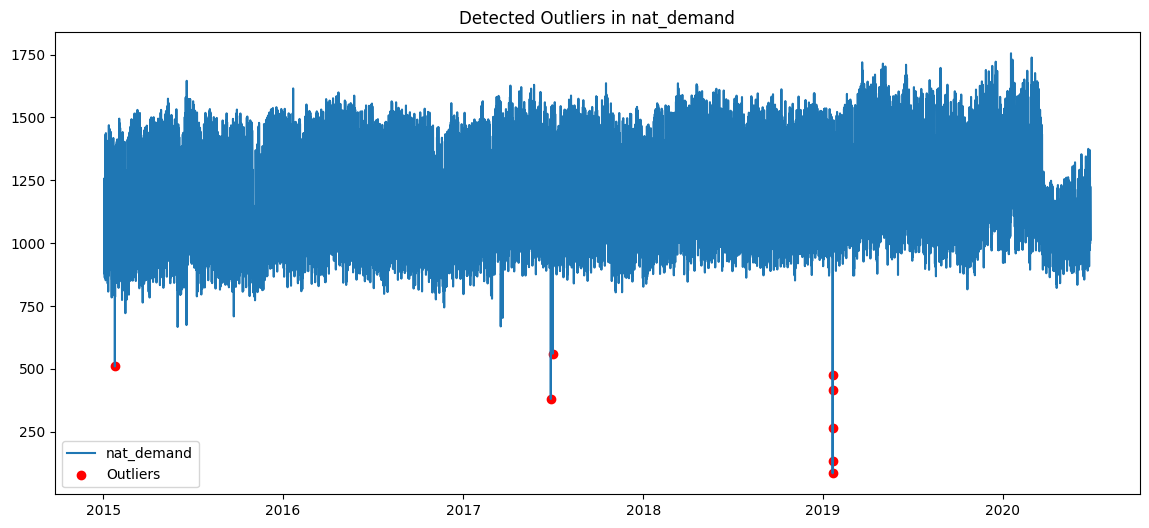

In [12]:
df['zscore'] = (df['nat_demand'] - df['nat_demand'].mean()) / df['nat_demand'].std()
outliers = df[np.abs(df['zscore']) > 3]

plt.figure(figsize=(14,6))
plt.plot(df.index, df['nat_demand'], label='nat_demand')
plt.scatter(outliers.index, outliers['nat_demand'], color='red', label='Outliers')
plt.title('Detected Outliers in nat_demand')
plt.legend()
plt.show()

In [13]:
df['nat_demand_original'] = df['nat_demand'].copy()

In [14]:
window = 5
rolling_med = df['nat_demand'].rolling(window=window, center=True).median()

mask = np.abs(df['zscore']) > 3
df.loc[mask, 'nat_demand'] = rolling_med[mask]

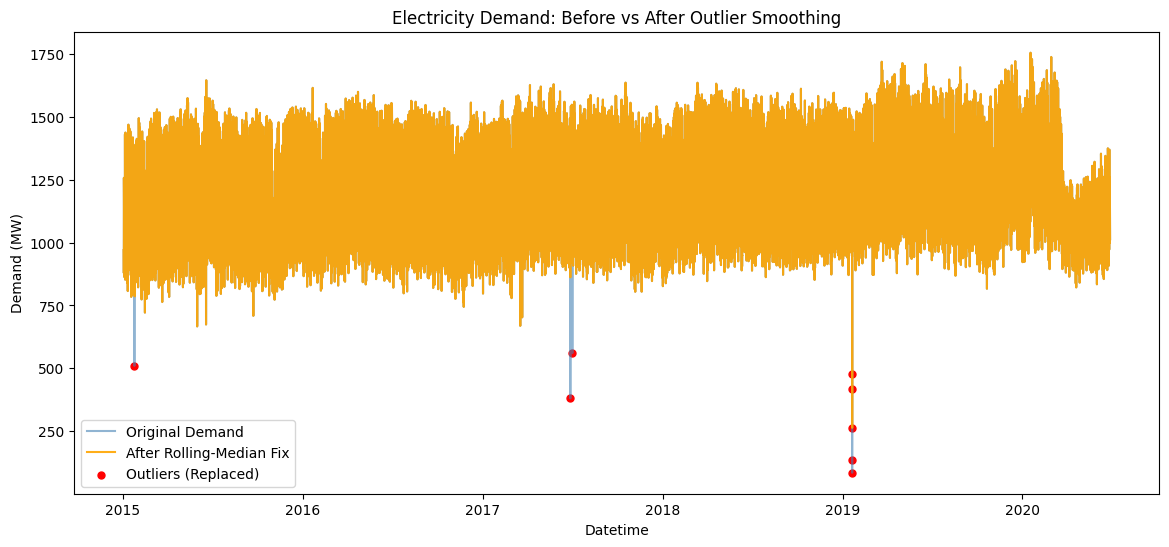

In [21]:
plt.figure(figsize=(14,6))
plt.plot(df.index, df['nat_demand_original'], label='Original Demand', color='steelblue', alpha=0.6)
plt.plot(df.index, df['nat_demand'], label='After Rolling-Median Fix', color='orange', alpha=0.9)
plt.scatter(df.index[mask], df.loc[mask, 'nat_demand_original'],
            color='red', s=25, label='Outliers (Replaced)')
plt.title('Electricity Demand: Before vs After Outlier Smoothing')
plt.xlabel('Datetime'); plt.ylabel('Demand (MW)')
plt.legend()
plt.show()

In [15]:
df.drop(columns=['zscore', 'nat_demand_original'], inplace=True)

In [16]:
df['hour']      = df.index.hour
df['dow']       = df.index.dayofweek
df['hour_sin']  = np.sin(2*np.pi*df['hour']/24);  df['hour_cos']  = np.cos(2*np.pi*df['hour']/24)
df['dow_sin']   = np.sin(2*np.pi*df['dow']/7);    df['dow_cos']   = np.cos(2*np.pi*df['dow']/7)
df.drop(columns=['hour','dow'], inplace=True)

In [17]:
split_idx = int(len(df)*0.8)
df_train  = df.iloc[:split_idx].copy()
df_test   = df.iloc[split_idx:].copy()

In [25]:
df_train.columns

Index(['nat_demand', 'T2M_toc', 'QV2M_toc', 'TQL_toc', 'W2M_toc', 'T2M_san',
       'QV2M_san', 'TQL_san', 'W2M_san', 'T2M_dav', 'QV2M_dav', 'TQL_dav',
       'W2M_dav', 'Holiday_ID', 'holiday', 'school', 'hour_sin', 'hour_cos',
       'dow_sin', 'dow_cos'],
      dtype='object')

In [18]:
x_scaler = MinMaxScaler()
x_scaler.fit(df_train.values)

train_scaled = pd.DataFrame(x_scaler.transform(df_train.values), 
                            index=df_train.index, columns=df_train.columns)
test_scaled  = pd.DataFrame(x_scaler.transform(df_test.values),
                            index=df_test.index, columns=df_test.columns)

y_scaler = MinMaxScaler()
y_scaler.fit(df_train[['nat_demand']].values)

MinMaxScaler()

In [19]:
def make_sequences(scaled_df, target_col='nat_demand', lookback=24, horizon=1):
    X, y, idx_end = [], [], []
    target_idx = scaled_df.columns.get_loc(target_col)
    data = scaled_df.values
    for i in range(lookback, len(scaled_df) - horizon + 1):
        X.append(data[i-lookback:i, :])                       # [lookback, n_features]
        y.append(data[i + horizon - 1, target_idx])           # scalar (scaled)
        idx_end.append(scaled_df.index[i + horizon - 1])      # timestamp of label
    return np.array(X), np.array(y), np.array(idx_end)

In [33]:
LOOKBACK = 24
HORIZON  = 1

In [34]:
X_train, y_train, t_train = make_sequences(train_scaled, lookback=LOOKBACK, horizon=HORIZON)
X_test,  y_test,  t_test  = make_sequences(test_scaled,  lookback=LOOKBACK, horizon=HORIZON)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((38414, 24, 20), (38414,), (9586, 24, 20), (9586,))

In [35]:
n_features = X_train.shape[2]

In [36]:
n_features

20

In [32]:
def invert_y(y_scaled):
    try:
        return y_scaler.inverse_transform(y_scaled.reshape(-1,1)).ravel()
    except Exception:
        return y_scaled

In [33]:
def build_gru_model(lookback, n_features):
    model = Sequential([
        GRU(128, return_sequences=True, input_shape=(lookback, n_features)),
        Dropout(0.2),
        GRU(64),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

In [34]:
def build_lstm_model(lookback, n_features):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(lookback, n_features)),
        Dropout(0.2),
        LSTM(64),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

In [35]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)
]

In [36]:
gru = build_gru_model(LOOKBACK, n_features)
hist_gru = gru.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

I0000 00:00:1761917199.256731      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50


I0000 00:00:1761917204.137545      99 cuda_dnn.cc:529] Loaded cuDNN version 90300


601/601 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0163 - val_loss: 0.0024 - learning_rate: 0.0010
Epoch 2/50
601/601 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0012 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 3/50
601/601 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 8.9257e-04 - val_loss: 0.0013 - learning_rate: 0.0010
Epoch 4/50
601/601 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 7.0183e-04 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 5/50
601/601 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 6.1328e-04 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 6/50
601/601 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5.3926e-04 - val_loss: 9.2519e-04 - learning_rate: 0.0010
Epoch 7/50
601/601 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 4.5494e-04 - val_loss: 8.4023e-04 - learning_rate: 0.0010
Epoch 8/50
601/601 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 4.3771e-04 - val_loss: 8.0434e-04 - learning_rate: 0.0010
Epoch 9/50
601/601 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 3.9882e-04 - val_loss: 6.5830e-04 

In [37]:
y_pred_gru_s = gru.predict(X_test).ravel()
y_true = invert_y(y_test)           
y_pred_gru = invert_y(y_pred_gru_s)

300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [38]:
rmse_gru = np.sqrt(mean_squared_error(y_true, y_pred_gru))
mae_gru  = mean_absolute_error(y_true, y_pred_gru)
print(f"[GRU] RMSE: {rmse_gru:.3f}   MAE: {mae_gru:.3f}")

[GRU] RMSE: 28.254   MAE: 19.900


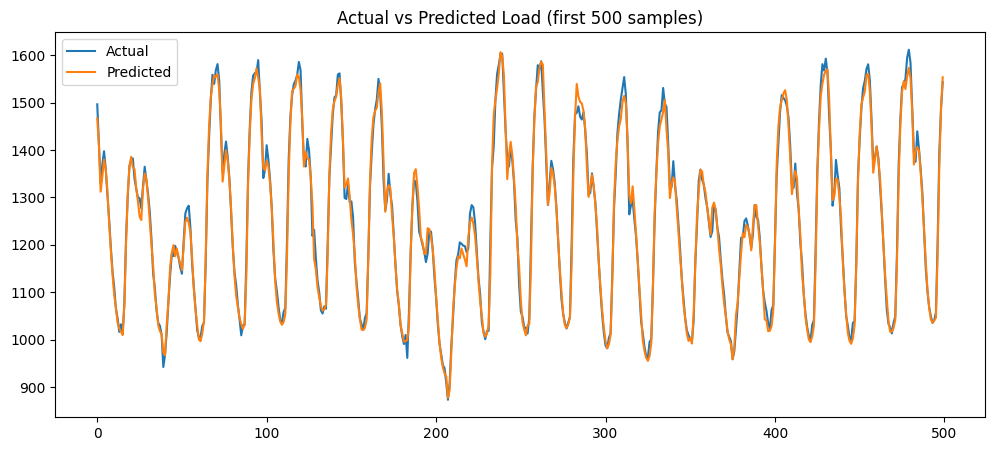

In [39]:
plt.figure(figsize=(12,5))
plt.plot(y_true[:500], label="Actual")
plt.plot(y_pred_gru[:500], label="Predicted")
plt.title("Actual vs Predicted Load (first 500 samples)")
plt.legend(); plt.show()

In [40]:
lstm = build_lstm_model(LOOKBACK, n_features)
hist_lstm = lstm.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
601/601 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.0140 - val_loss: 0.0053 - learning_rate: 0.0010
Epoch 2/50
601/601 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0016 - val_loss: 0.0031 - learning_rate: 0.0010
Epoch 3/50
601/601 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0010 - val_loss: 0.0027 - learning_rate: 0.0010
Epoch 4/50
601/601 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 8.4637e-04 - val_loss: 0.0030 - learning_rate: 0.0010
Epoch 5/50
601/601 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 7.1736e-04 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 6/50
601/601 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 6.4462e-04 - val_loss: 0.0017 - learning_rate: 0.0010
Epoch 7/50
601/601 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5.3846e-04 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 8/50
601/601 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 4.4093e-04 - val_loss: 0.0010 - learning_rate: 0.0010
Epoch 9/50
601/601 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 4.9277e-04 - val_loss: 9.0032e-04 - lea

In [41]:
y_pred_lstm_s = lstm.predict(X_test).ravel()
y_pred_lstm = invert_y(y_pred_lstm_s)

300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [42]:
rmse_lstm = np.sqrt(mean_squared_error(y_true, y_pred_lstm))
mae_lstm  = mean_absolute_error(y_true, y_pred_lstm)
print(f"[LSTM] RMSE: {rmse_lstm:.3f}   MAE: {mae_lstm:.3f}")

[LSTM] RMSE: 27.820   MAE: 19.339


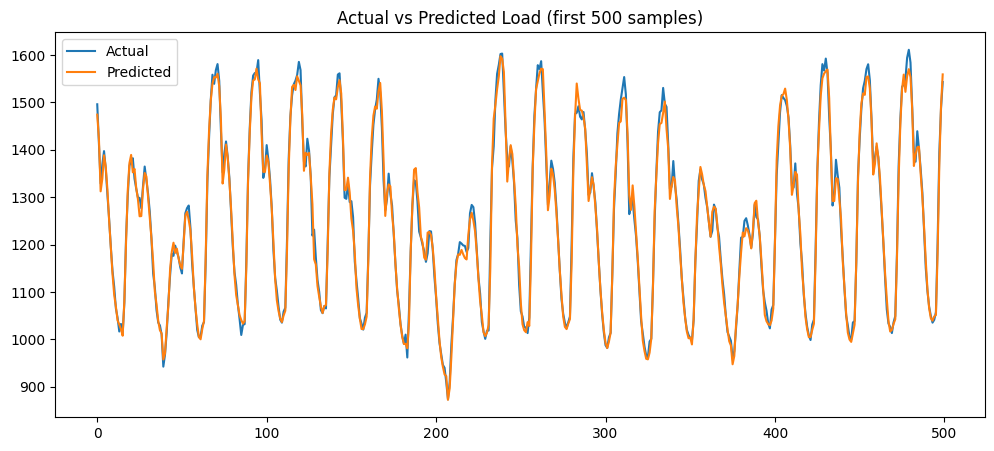

In [43]:
plt.figure(figsize=(12,5))
plt.plot(y_true[:500], label="Actual")
plt.plot(y_pred_lstm[:500], label="Predicted")
plt.title("Actual vs Predicted Load (first 500 samples)")
plt.legend(); plt.show()

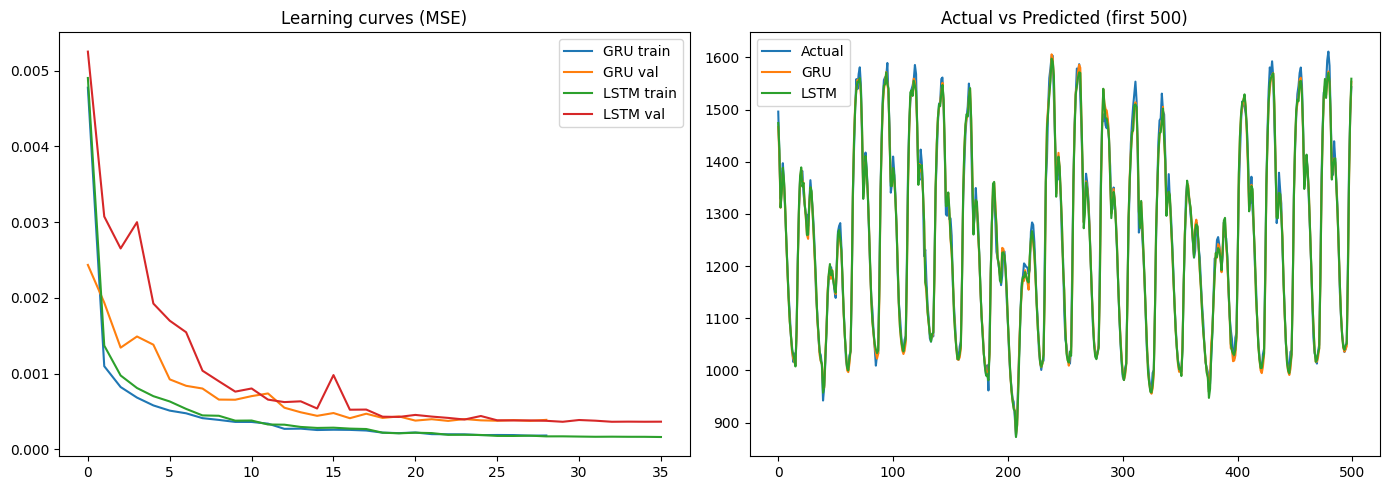

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(hist_gru.history['loss'], label='GRU train')
axes[0].plot(hist_gru.history['val_loss'], label='GRU val')
axes[0].plot(hist_lstm.history['loss'], label='LSTM train')
axes[0].plot(hist_lstm.history['val_loss'], label='LSTM val')
axes[0].set_title("Learning curves (MSE)"); axes[0].legend()

show_n = min(500, len(y_true))
axes[1].plot(y_true[:show_n], label='Actual')
axes[1].plot(y_pred_gru[:show_n], label='GRU')
axes[1].plot(y_pred_lstm[:show_n], label='LSTM')
axes[1].set_title(f"Actual vs Predicted (first {show_n})"); axes[1].legend()

plt.tight_layout(); plt.show()